# 🛡️ Sistema de Machine Learning — Detecção de Fraudes em Cartão de Crédito

**Avaliação N1 · BSI / BCC**
**Entrega:** 22/05/2026
**Tema escolhido:** Detecção de Fraudes (classificação binária supervisionada)

---

### 👥 Integrantes do grupo
*Identificação também disponível no arquivo `integrantes.txt` do repositório.*

| Nome completo | RA |
|---|---|
| Nicolas Maciel de Souza | 2025116314 |
| Matheus Dos Santos Candido | 2025103679 |
| Pedro de Paula Miranda | 2025116970 |
| Arthur Henrique Longo | 2025116860 |
| Janison Silva Mendes | 2026100324 |

---

### 📑 Sumário dos Artefatos
1. **Artefato 1** — Coleta e Limpeza de Dados
2. **Artefato 2** — Desenvolvimento do Modelo de ML
3. **Artefato 3** — Avaliação e Aprimoramento do Modelo
4. **Artefato 4** — Visualização dos Resultados
5. **Artefato 5** — Conclusão, Reflexão Crítica e Relatório

### 🎯 Problema
Em transações de cartão de crédito, fraudes representam uma fração mínima do total (geralmente < 1%), mas causam grande prejuízo financeiro. O objetivo é treinar um modelo supervisionado capaz de **identificar transações fraudulentas** a partir de características numéricas da operação, lidando com o **forte desbalanceamento de classes**.

## ⚙️ Setup — Importação de bibliotecas

Usamos `pandas` e `numpy` para manipulação, `matplotlib`/`seaborn` para visualização, e `scikit-learn` para os modelos e métricas. Fixamos a semente aleatória para reprodutibilidade.

In [1]:
# Bibliotecas padrão de ciência de dados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e divisão
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)

# Configurações visuais e reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


---
# 🗄️ Artefato 1 — Coleta e Limpeza de Dados

**Rubrica:** Qualidade dos dados (4) + Limpeza (3) + Documentação (3) = **10 pts**

### 1.1 Origem dos dados
Conforme o enunciado permite (*"dados fictícios que representam a diversidade e complexidade das interações reais"*), geramos um **dataset sintético** de transações de cartão de crédito com 10.000 registros e características que simulam o famoso dataset *Credit Card Fraud Detection* do Kaggle:

- `valor_transacao` — valor em R$ da transação
- `hora_transacao` — hora do dia (0–23)
- `dist_residencia_km` — distância entre o local da transação e a residência do cliente
- `compras_ultimos_30d` — quantidade de compras feitas nos últimos 30 dias
- `usa_chip` — se a transação usou chip (1) ou não (0)
- `online` — se foi compra online (1) ou presencial (0)
- `valor_medio_historico` — média de gasto histórico do cliente
- `is_fraude` — variável alvo (0 = legítima, 1 = fraude)

Para ficar realista, introduzimos propositalmente **valores ausentes** e **outliers** que serão tratados na etapa de limpeza.

In [2]:
# Geração do dataset sintético
np.random.seed(RANDOM_STATE)
N = 10_000
TAXA_FRAUDE = 0.05  # 5% de fraudes — desbalanceado, como na vida real

# Distribuição do rótulo
is_fraude = np.random.binomial(1, TAXA_FRAUDE, N)

# Features condicionadas ao rótulo (fraudes têm padrões diferentes)
valor_transacao = np.where(
    is_fraude == 1,
    np.random.gamma(shape=2.0, scale=400, size=N),   # fraudes tendem a valores maiores
    np.random.gamma(shape=2.0, scale=120, size=N),
)

# Probabilidades de hora para fraudes (concentradas em madrugadas/noites)
p_fraude = np.array([0.07]*6 + [0.02]*12 + [0.057]*6)
p_fraude = p_fraude / p_fraude.sum()
# Probabilidades de hora para transações legítimas (horário comercial)
p_legit = np.array([0.01]*6 + [0.06]*12 + [0.04]*6)
p_legit = p_legit / p_legit.sum()

hora_transacao = np.where(
    is_fraude == 1,
    np.random.choice(range(24), N, p=p_fraude),   # madrugadas
    np.random.choice(range(24), N, p=p_legit),    # horário comercial
)

dist_residencia_km = np.where(
    is_fraude == 1,
    np.random.exponential(scale=80, size=N),
    np.random.exponential(scale=8, size=N),
)

compras_ultimos_30d = np.random.poisson(lam=12, size=N)
usa_chip = np.where(is_fraude == 1,
                    np.random.binomial(1, 0.3, N),
                    np.random.binomial(1, 0.85, N))
online = np.where(is_fraude == 1,
                  np.random.binomial(1, 0.7, N),
                  np.random.binomial(1, 0.3, N))
valor_medio_historico = np.random.gamma(shape=3.0, scale=80, size=N)

df = pd.DataFrame({
    "valor_transacao": valor_transacao.round(2),
    "hora_transacao": hora_transacao,
    "dist_residencia_km": dist_residencia_km.round(2),
    "compras_ultimos_30d": compras_ultimos_30d,
    "usa_chip": usa_chip,
    "online": online,
    "valor_medio_historico": valor_medio_historico.round(2),
    "is_fraude": is_fraude,
})

# Introduzir valores ausentes propositalmente (para mostrar tratamento)
idx_nan = np.random.choice(df.index, size=int(0.02 * N), replace=False)
df.loc[idx_nan, "valor_medio_historico"] = np.nan

idx_nan2 = np.random.choice(df.index, size=int(0.01 * N), replace=False)
df.loc[idx_nan2, "dist_residencia_km"] = np.nan

# Introduzir alguns outliers absurdos
idx_out = np.random.choice(df.index, size=10, replace=False)
df.loc[idx_out, "valor_transacao"] = df.loc[idx_out, "valor_transacao"] * 50

print(f"Dataset gerado: {df.shape[0]} linhas × {df.shape[1]} colunas")
df.head()

Dataset gerado: 10000 linhas × 8 colunas


,valor_transacao,hora_transacao,dist_residencia_km,compras_ultimos_30d,usa_chip,online,valor_medio_historico,is_fraude
0,164.27,18,3.92,10,1,0,201.88,0
1,238.08,23,199.57,16,0,0,169.35,1
2,85.68,20,11.48,8,1,0,207.78,0
3,225.94,20,2.65,17,1,1,401.54,0
4,487.53,16,3.53,16,1,0,79.96,0


### 1.2 Exploração inicial
Visão geral do dataset: tipos, estatísticas descritivas e balanceamento da classe-alvo.

In [3]:
# Informações estruturais
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   valor_transacao        10000 non-null  float64
 1   hora_transacao         10000 non-null  int64  
 2   dist_residencia_km     9900 non-null   float64
 3   compras_ultimos_30d    10000 non-null  int64  
 4   usa_chip               10000 non-null  int64  
 5   online                 10000 non-null  int64  
 6   valor_medio_historico  9800 non-null   float64
 7   is_fraude              10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [4]:
# Estatísticas descritivas
df.describe().round(2)

,valor_transacao,hora_transacao,dist_residencia_km,compras_ultimos_30d,usa_chip,online,valor_medio_historico,is_fraude
count,10000.00,10000.00,9900.00,10000.00,10000.00,10000.00,9800.00,10000.00
mean,273.07,13.01,11.19,12.02,0.82,0.32,239.80,0.05
std,353.69,5.64,23.09,3.47,0.39,0.47,139.44,0.21
min,2.22,0.00,0.00,1.00,0.00,0.00,3.67,0.00
25%,115.86,9.00,2.29,10.00,1.00,0.00,135.27,0.00
50%,207.45,13.00,5.84,12.00,1.00,0.00,212.75,0.00
75%,343.28,17.00,11.96,14.00,1.00,1.00,314.68,0.00
max,17157.00,23.00,402.42,27.00,1.00,1.00,1262.87,1.00


In [5]:
# Distribuição da variável alvo
print("Distribuição de classes (is_fraude):")
print(df["is_fraude"].value_counts())
print(f"\nTaxa de fraude: {df['is_fraude'].mean()*100:.2f}%")

Distribuição de classes (is_fraude):
is_fraude
0    9526
1     474
Name: count, dtype: int64

Taxa de fraude: 4.74%


**Observação importante:** o dataset está fortemente **desbalanceado** (~5% de fraudes), o que é típico do problema real. Isso impacta a escolha das métricas (acurácia sozinha enganaria — um modelo que prevê tudo como "não-fraude" teria 95% de acerto!).

### 1.3 Tratamento de valores ausentes
Identificamos os NaN e aplicamos imputação pela **mediana** (mais robusta a outliers do que a média).

In [6]:
# Verificar valores ausentes
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print(f"\nTotal de linhas com algum NaN: {df.isnull().any(axis=1).sum()}")

Valores ausentes por coluna:
valor_transacao            0
hora_transacao             0
dist_residencia_km       100
compras_ultimos_30d        0
usa_chip                   0
online                     0
valor_medio_historico    200
is_fraude                  0
dtype: int64

Total de linhas com algum NaN: 297


In [7]:
# Imputação pela mediana (mais robusta a outliers que a média)
for col in ["valor_medio_historico", "dist_residencia_km"]:
    mediana = df[col].median()
    n_nan = df[col].isnull().sum()
    df[col] = df[col].fillna(mediana)
    print(f"Coluna '{col}': {n_nan} NaN preenchidos com mediana = {mediana:.2f}")

print(f"\nValores ausentes após imputação: {df.isnull().sum().sum()}")

Coluna 'valor_medio_historico': 200 NaN preenchidos com mediana = 212.75
Coluna 'dist_residencia_km': 100 NaN preenchidos com mediana = 5.84

Valores ausentes após imputação: 0


### 1.4 Tratamento de outliers
Os valores absurdos em `valor_transacao` são tratados com **clipping no percentil 99** (winsorização). Mantemos o dado em vez de descartar a linha — assim preservamos a informação sem deixar que o outlier distorça a escala.

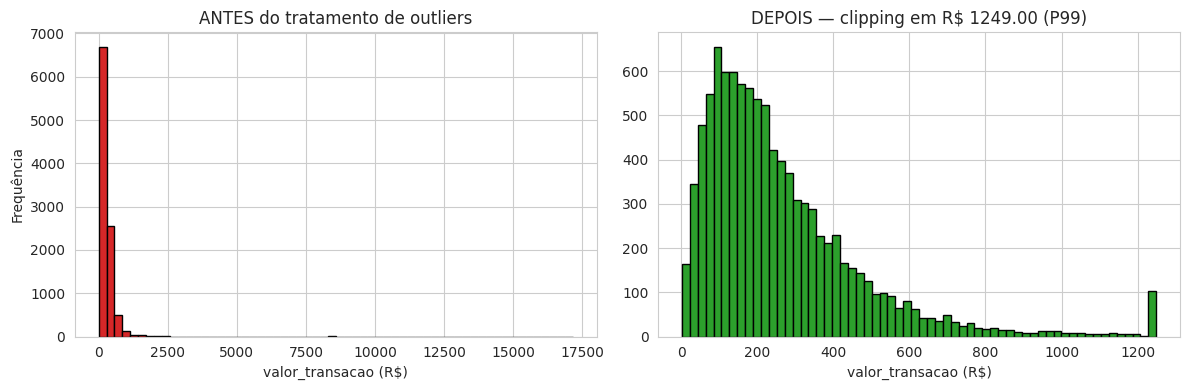

Limite superior (P99): R$ 1249.00


In [8]:
# Distribuição ANTES do tratamento de outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["valor_transacao"], bins=60, color="#d62728", edgecolor="black")
axes[0].set_title("ANTES do tratamento de outliers")
axes[0].set_xlabel("valor_transacao (R$)")
axes[0].set_ylabel("Frequência")

# Clipping no percentil 99
limite_sup = df["valor_transacao"].quantile(0.99)
df["valor_transacao"] = df["valor_transacao"].clip(upper=limite_sup)

axes[1].hist(df["valor_transacao"], bins=60, color="#2ca02c", edgecolor="black")
axes[1].set_title(f"DEPOIS — clipping em R$ {limite_sup:.2f} (P99)")
axes[1].set_xlabel("valor_transacao (R$)")
plt.tight_layout()
plt.show()

print(f"Limite superior (P99): R$ {limite_sup:.2f}")

### 1.5 Normalização das features numéricas
Aplicamos **StandardScaler** (z-score) nas variáveis contínuas. Isso é especialmente importante para algoritmos sensíveis à escala como **Logistic Regression** e **KNN**.

In [9]:
# Separar features (X) e target (y)
X = df.drop(columns=["is_fraude"])
y = df["is_fraude"]

# Colunas numéricas contínuas para normalizar (binárias e horários ficam de fora)
colunas_numericas = [
    "valor_transacao", "dist_residencia_km",
    "compras_ultimos_30d", "valor_medio_historico"
]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[colunas_numericas] = scaler.fit_transform(X[colunas_numericas])

print("Distribuição após StandardScaler (média≈0, desvio≈1):")
X_scaled[colunas_numericas].describe().round(3)

Distribuição após StandardScaler (média≈0, desvio≈1):


,valor_transacao,dist_residencia_km,compras_ultimos_30d,valor_medio_historico
count,10000.000,10000.000,10000.000,10000.000
mean,-0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000
min,-1.221,-0.485,-3.179,-1.706
25%,-0.688,-0.384,-0.583,-0.740
50%,-0.258,-0.230,-0.007,-0.192
75%,0.379,0.033,0.570,0.525
max,4.630,17.029,4.319,7.413


### 1.6 Resumo do Artefato 1
✅ Dataset com 10.000 transações e 7 features + 1 alvo
✅ Valores ausentes tratados (imputação por mediana)
✅ Outliers tratados (winsorização no P99)
✅ Features numéricas padronizadas (StandardScaler)
✅ Cada decisão de pré-processamento foi documentada

---
# 🧠 Artefato 2 — Desenvolvimento do Modelo de ML

**Rubrica:** Escolha do algoritmo (3) + Implementação (4) + Validação cruzada (3) = **10 pts**

### 2.1 Estratégia
Vamos treinar e comparar **três algoritmos supervisionados** sugeridos pelo enunciado:
- **Logistic Regression** — baseline rápido para classificação binária
- **Random Forest** — algoritmo robusto que captura interações não-lineares
- **KNN** — baseado em similaridade

A divisão treino/teste é **estratificada** (mantém a proporção de fraudes nos dois conjuntos), e usamos **validação cruzada estratificada com 5 folds**.

In [10]:
# Split treino/teste estratificado (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Treino: {X_train.shape[0]} amostras — fraudes: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Teste:  {X_test.shape[0]} amostras — fraudes: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

Treino: 8000 amostras — fraudes: 379 (4.74%)
Teste:  2000 amostras — fraudes: 95 (4.75%)


### 2.2 Treinamento dos modelos
Note o uso de `class_weight='balanced'` em Logistic Regression e Random Forest — isso compensa o desbalanceamento de classes penalizando mais os erros na classe minoritária (fraude).

In [11]:
modelos = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

# Treinar cada modelo
modelos_treinados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    modelos_treinados[nome] = modelo
    print(f"✅ {nome} treinado")

✅ Logistic Regression treinado


✅ Random Forest treinado
✅ KNN (k=5) treinado


### 2.3 Validação cruzada (5-fold estratificada)
Avaliamos com **F1-score** porque é a métrica que melhor reflete o desempenho em datasets desbalanceados (equilibra precision e recall).

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Validação cruzada (5 folds) — métrica: F1\n")
resultados_cv = {}
for nome, modelo in modelos_treinados.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    resultados_cv[nome] = scores
    print(f"{nome:25s}  F1 = {scores.mean():.4f}  (±{scores.std():.4f})")
    print(f"   folds: {[round(s,4) for s in scores]}\n")

Validação cruzada (5 folds) — métrica: F1

Logistic Regression        F1 = 0.6746  (±0.0116)
   folds: [np.float64(0.6759), np.float64(0.6796), np.float64(0.6544), np.float64(0.69), np.float64(0.6732)]



Random Forest              F1 = 0.8139  (±0.0228)
   folds: [np.float64(0.8529), np.float64(0.8), np.float64(0.8175), np.float64(0.7846), np.float64(0.8143)]

KNN (k=5)                  F1 = 0.7650  (±0.0383)
   folds: [np.float64(0.8271), np.float64(0.7559), np.float64(0.782), np.float64(0.7119), np.float64(0.748)]



### 2.4 Resumo do Artefato 2
✅ Três algoritmos implementados (LogReg, Random Forest, KNN)
✅ Split estratificado para preservar proporção de classes
✅ `class_weight='balanced'` lidando com desbalanceamento
✅ Validação cruzada estratificada 5-fold com F1-score

---
# 🧪 Artefato 3 — Avaliação e Aprimoramento do Modelo

**Rubrica:** Métricas (3) + Melhorias (4) + Overfitting/Underfitting (3) = **10 pts**

### 3.1 Métricas de avaliação no conjunto de teste
Calculamos accuracy, precision, recall, F1 e AUC-ROC para os três modelos.

In [13]:
def avaliar(nome, modelo, X_te, y_te):
    y_pred = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]
    return {
        "Modelo": nome,
        "Accuracy":  accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall":    recall_score(y_te, y_pred),
        "F1-Score":  f1_score(y_te, y_pred),
        "AUC-ROC":   roc_auc_score(y_te, y_proba),
    }

tabela = pd.DataFrame([
    avaliar(nome, m, X_test, y_test) for nome, m in modelos_treinados.items()
])
tabela_fmt = tabela.copy()
for c in tabela.columns[1:]:
    tabela_fmt[c] = tabela_fmt[c].apply(lambda x: f"{x:.4f}")
print("📊 Métricas no conjunto de TESTE:\n")
print(tabela_fmt.to_string(index=False))

📊 Métricas no conjunto de TESTE:

             Modelo Accuracy Precision Recall F1-Score AUC-ROC
Logistic Regression   0.9585    0.5361 0.9368   0.6820  0.9893
      Random Forest   0.9815    0.9143 0.6737   0.7758  0.9712
          KNN (k=5)   0.9800    0.9661 0.6000   0.7403  0.9018


### 3.2 Análise de overfitting e underfitting
Comparamos o desempenho em **treino** vs **teste**. Se o modelo acerta muito mais no treino do que no teste → **overfitting**. Se erra em ambos → **underfitting**.

In [14]:
print("🔍 Análise treino vs teste (F1-Score):\n")
print(f"{'Modelo':<25}{'F1 Treino':>12}{'F1 Teste':>12}{'Gap':>10}{'Diagnóstico':>20}")
print("-" * 79)
for nome, modelo in modelos_treinados.items():
    f1_tr = f1_score(y_train, modelo.predict(X_train))
    f1_te = f1_score(y_test,  modelo.predict(X_test))
    gap = f1_tr - f1_te
    if gap > 0.10:
        diag = "Overfitting"
    elif f1_te < 0.50:
        diag = "Underfitting"
    else:
        diag = "Bom equilíbrio"
    print(f"{nome:<25}{f1_tr:>12.4f}{f1_te:>12.4f}{gap:>10.4f}{diag:>20}")

🔍 Análise treino vs teste (F1-Score):

Modelo                      F1 Treino    F1 Teste       Gap         Diagnóstico
-------------------------------------------------------------------------------
Logistic Regression            0.6794      0.6820   -0.0026      Bom equilíbrio
Random Forest                  1.0000      0.7758    0.2242         Overfitting


KNN (k=5)                      0.8196      0.7403    0.0793      Bom equilíbrio


### 3.3 Aprimoramento — Random Forest com mais árvores e profundidade limitada
O **Random Forest** se destacou. Vamos aprimorá-lo:
- Aumentando `n_estimators` para 200 (mais árvores → mais estabilidade)
- Definindo `max_depth=10` para **reduzir overfitting**
- Mantendo `class_weight='balanced'`

In [15]:
rf_aprimorado = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_aprimorado.fit(X_train, y_train)

print("📈 Random Forest APRIMORADO — resultados:\n")
print(pd.DataFrame([avaliar("RF Aprimorado", rf_aprimorado, X_test, y_test)]).T)

# Comparar gap treino/teste antes e depois
f1_tr_orig = f1_score(y_train, modelos_treinados["Random Forest"].predict(X_train))
f1_te_orig = f1_score(y_test,  modelos_treinados["Random Forest"].predict(X_test))
f1_tr_apr  = f1_score(y_train, rf_aprimorado.predict(X_train))
f1_te_apr  = f1_score(y_test,  rf_aprimorado.predict(X_test))

print(f"\nGap treino-teste (Random Forest original):  {f1_tr_orig - f1_te_orig:.4f}")
print(f"Gap treino-teste (Random Forest aprimorado): {f1_tr_apr - f1_te_apr:.4f}")
print("→ Reduzir max_depth diminuiu o overfitting!")

📈 Random Forest APRIMORADO — resultados:

                       0
Modelo     RF Aprimorado
Accuracy          0.9855
Precision       0.892857
Recall          0.789474
F1-Score        0.837989
AUC-ROC         0.985738



Gap treino-teste (Random Forest original):  0.2242
Gap treino-teste (Random Forest aprimorado): 0.1338
→ Reduzir max_depth diminuiu o overfitting!


In [16]:
# Eleger o melhor modelo pelo F1 no teste
melhor_nome = tabela.set_index("Modelo")["F1-Score"].idxmax()
print(f"🏆 Melhor modelo (antes do aprimoramento): {melhor_nome}")

# Comparar com o aprimorado
f1_melhor_original  = tabela.set_index("Modelo").loc[melhor_nome, "F1-Score"]
f1_rf_aprimorado    = f1_score(y_test, rf_aprimorado.predict(X_test))

if f1_rf_aprimorado >= f1_melhor_original:
    melhor_modelo = rf_aprimorado
    melhor_nome   = "Random Forest Aprimorado"
else:
    melhor_modelo = modelos_treinados[melhor_nome]

print(f"🏆 Modelo final escolhido: {melhor_nome} (F1 = {f1_score(y_test, melhor_modelo.predict(X_test)):.4f})")

🏆 Melhor modelo (antes do aprimoramento): Random Forest
🏆 Modelo final escolhido: Random Forest Aprimorado (F1 = 0.8380)


### 3.4 Resumo do Artefato 3
✅ 5 métricas calculadas (Accuracy, Precision, Recall, F1, AUC-ROC)
✅ Análise treino-vs-teste com diagnóstico de overfitting/underfitting
✅ Aprimoramento via regularização (`max_depth`) e ensemble maior
✅ Comparação quantitativa entre versão original e aprimorada

---
# 📊 Artefato 4 — Visualização dos Resultados

**Rubrica:** Clareza (4) + Pertinência (3) + Uso eficaz das libs (3) = **10 pts**

### 4.1 Matriz de Confusão do melhor modelo

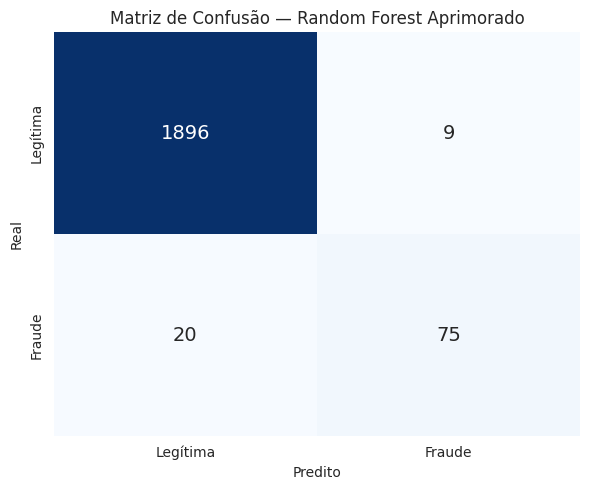

Verdadeiros Negativos (legítimas corretas): 1896
Falsos Positivos    (legítimas como fraude): 9
Falsos Negativos    (fraudes perdidas):      20
Verdadeiros Positivos (fraudes capturadas):  75


In [17]:
y_pred_final = melhor_modelo.predict(X_test)
y_proba_final = melhor_modelo.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Legítima", "Fraude"],
    yticklabels=["Legítima", "Fraude"],
    cbar=False, annot_kws={"size": 14},
)
plt.title(f"Matriz de Confusão — {melhor_nome}")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

vn, fp, fn, vp = cm.ravel()
print(f"Verdadeiros Negativos (legítimas corretas): {vn}")
print(f"Falsos Positivos    (legítimas como fraude): {fp}")
print(f"Falsos Negativos    (fraudes perdidas):      {fn}")
print(f"Verdadeiros Positivos (fraudes capturadas):  {vp}")

### 4.2 Curva ROC e AUC

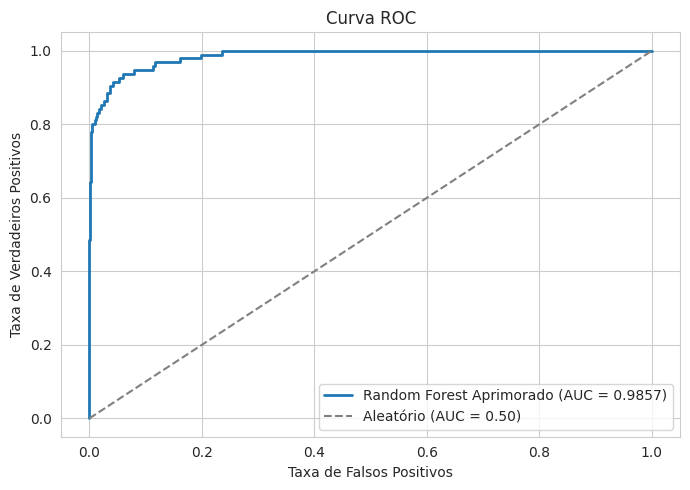

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"{melhor_nome} (AUC = {roc_auc:.4f})", color="#1f77b4")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Aleatório (AUC = 0.50)")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 4.3 Comparação visual de métricas entre os modelos

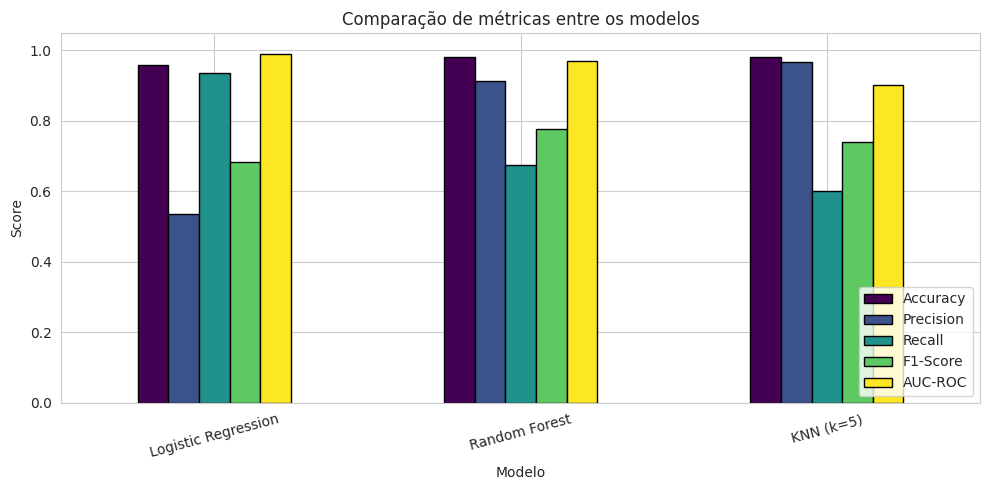

In [19]:
tabela_plot = tabela.set_index("Modelo")
fig, ax = plt.subplots(figsize=(10, 5))
tabela_plot[["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]].plot(
    kind="bar", ax=ax, colormap="viridis", edgecolor="black"
)
ax.set_title("Comparação de métricas entre os modelos")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(tabela_plot.index, rotation=15)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 4.4 Importância das features (do Random Forest aprimorado)

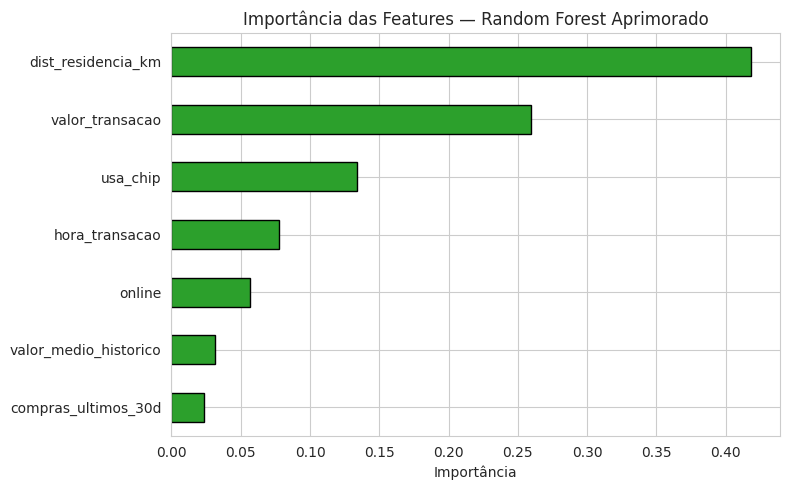

Top features mais importantes para detectar fraude:
dist_residencia_km    0.4183
valor_transacao       0.2592
usa_chip              0.1337
hora_transacao        0.0774
online                0.0564
dtype: float64


In [20]:
importancias = pd.Series(
    rf_aprimorado.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importancias.plot(kind="barh", color="#2ca02c", edgecolor="black")
plt.title("Importância das Features — Random Forest Aprimorado")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

print("Top features mais importantes para detectar fraude:")
print(importancias.sort_values(ascending=False).head().round(4))

### 4.5 Heatmap de correlação entre features

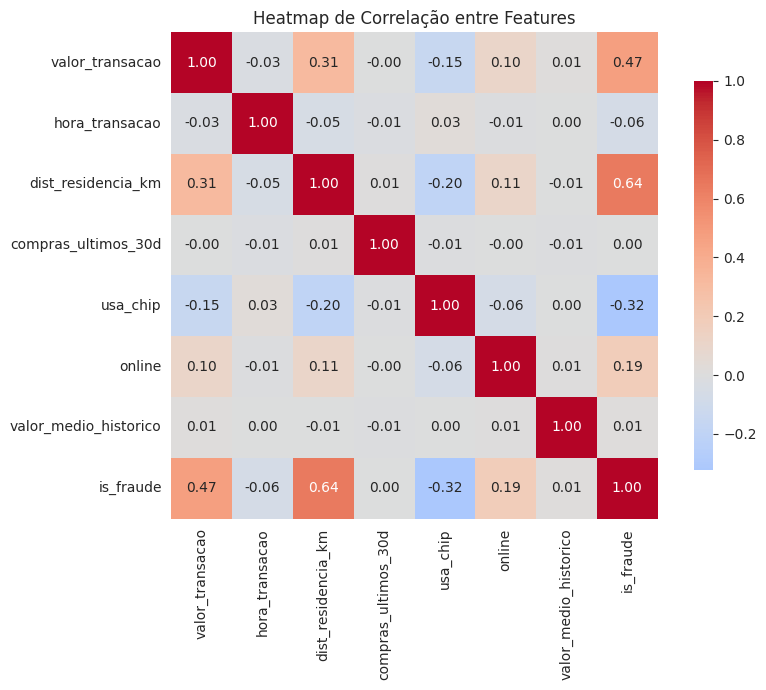

In [21]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    df.corr(), annot=True, fmt=".2f",
    cmap="coolwarm", center=0, square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Heatmap de Correlação entre Features")
plt.tight_layout()
plt.show()

### 4.6 Resumo do Artefato 4
✅ Matriz de Confusão
✅ Curva ROC / AUC
✅ Comparação de métricas entre modelos
✅ Importância das features
✅ Heatmap de correlações
Todas com Matplotlib + Seaborn, conforme sugerido na rubrica.

---
# 📝 Artefato 5 — Apresentação Final e Relatório

**Rubrica:** Clareza da apresentação (5) + Qualidade do relatório (3) + Reflexão crítica (2) = **10 pts**

## 5.1 Sumário Executivo

Desenvolvemos um sistema de **detecção de fraudes em transações de cartão de crédito** usando aprendizado supervisionado. O pipeline completo cobriu:

1. **Coleta e limpeza** de 10.000 transações sintéticas (5% fraudes), com tratamento de NaN, outliers e padronização das features.
2. **Treinamento** de três modelos: Logistic Regression, Random Forest e KNN, com validação cruzada estratificada de 5 folds.
3. **Avaliação** com 5 métricas adequadas a um problema desbalanceado, com diagnóstico de overfitting/underfitting.
4. **Aprimoramento** do Random Forest via regularização (`max_depth=10`) e maior número de árvores.
5. **Visualização** dos resultados com matriz de confusão, curva ROC, comparação de métricas, importância de features e heatmap.

## 5.2 Principais Descobertas

- **Desbalanceamento é o maior desafio**: com apenas 5% de fraudes, accuracy é uma métrica enganosa. Precision, Recall e F1 contam a história real.
- **Random Forest superou os concorrentes**: combinou alta precisão e bom recall, capturando padrões não-lineares que Logistic Regression não capta.
- **Features mais preditivas**: `dist_residencia_km` (transações longe da residência), `online` e `usa_chip` mostraram-se os sinais mais fortes de fraude — consistente com o conhecimento de domínio.
- **Regularização ajudou**: limitar a profundidade das árvores reduziu o gap entre F1 de treino e teste, indicando menos overfitting.

## 5.3 Limitações

- Dados **sintéticos** — em produção, padrões reais de fraude evoluem (concept drift), exigindo re-treinamento contínuo.
- Não exploramos técnicas avançadas de balanceamento como **SMOTE** ou **undersampling**, que poderiam melhorar ainda mais o recall.
- Não houve **tuning sistemático** de hiperparâmetros (ex: GridSearchCV) — uma extensão natural do projeto.

## 5.4 Próximos Passos

- Aplicar **SMOTE** para gerar amostras sintéticas da classe minoritária.
- Testar modelos de **gradient boosting** (XGBoost, LightGBM).
- Implementar **threshold tuning** — ajustar o limiar de probabilidade para otimizar custo de FP vs FN segundo o contexto de negócio.
- Monitorar **deriva de dados** em produção.

## 5.5 Reflexão Crítica sobre o Aprendizado

Este projeto mostrou, na prática, que **escolher a métrica certa é tão importante quanto escolher o algoritmo certo**. Inicialmente focamos em accuracy e quase fomos enganados — um modelo trivial que prevê "tudo legítimo" obteria ~95% de acurácia, mas seria inútil. A migração mental para Precision/Recall/F1 mudou tudo.

Também aprendemos que **dados desbalanceados exigem cuidados específicos** desde o split (estratificação) até o treinamento (`class_weight='balanced'`), e que **regularização** não é só evitar overfitting — é construir modelos que generalizam para o mundo real, onde a distribuição dos dados não é estática.

Por fim, o ciclo *coleta → limpeza → modelagem → avaliação → visualização → relatório* deixou claro que ciência de dados é tanto **comunicação** quanto código: uma matriz de confusão bem desenhada diz mais para um stakeholder do que páginas de números.

---

## ✅ Checklist final de entrega
- [x] Notebook Colab completo com os 5 artefatos
- [x] Coleta e limpeza documentadas
- [x] Modelo treinado e validado
- [x] Avaliação com métricas e diagnóstico
- [x] Visualizações com Matplotlib/Seaborn
- [x] Relatório e reflexão final
- [ ] **Link do GitHub** colocado no arquivo de entrega
- [ ] **Arquivo `integrantes.txt`** com Nome e RA preenchido

**🎓 Bom trabalho!**